# Semana 7 — Algoritmos Genéticos para o TSP
**Disciplina:** INF0415 — Heurísticas e Modelagem Multiobjetivo  
**Curso:** Bacharelado em Inteligência Artificial — UFG  
**Carga horária da prática:** ~2h em sala + finalização extraclasse  
**Avaliação:** TL (40% do componente prático)  
**Versão:** ALUNO

---

## Contextualização

Nas Semanas 5 e 6, vocês implementaram três métodos de busca local — **Hill Climbing**, **Simulated Annealing** e **Busca Tabu** — todos baseados em **uma única solução por vez** (paradigma de trajetória). Esses métodos têm uma limitação estrutural: a busca depende fortemente do ponto de partida, e a única "memória" que existe (em SA e Tabu) refere-se ao próprio caminho percorrido.

Nesta semana iniciamos o **paradigma populacional**. Em vez de uma solução, manteremos uma **população** delas evoluindo simultaneamente, inspirados no mecanismo darwiniano de seleção natural. As soluções competem, se reproduzem (combinando características via *crossover*) e sofrem variações aleatórias (*mutação*). A diversidade da população é uma forma implícita de memória: regiões promissoras do espaço de busca ficam representadas por múltiplos indivíduos.

**Problema de base:** mantemos o **TSP simétrico** das semanas anteriores. A comparação direta com os resultados de Tabu Search (Semana 6) é deliberada — ela vai mostrar onde cada paradigma brilha.

**Framework:** usaremos o **DEAP** (*Distributed Evolutionary Algorithms in Python*), um dos pacotes mais consolidados da comunidade de computação evolutiva. Ele será reutilizado nas Semanas 8 e 9.


## Objetivos da prática

Ao final desta atividade, você será capaz de:

1. **Identificar** os componentes canônicos de um Algoritmo Genético: representação, operadores de seleção, *crossover*, mutação, substituição e elitismo.
2. **Justificar** por que operadores de *crossover* de 1-ponto/2-pontos **não funcionam** em representações de permutação, e o que os operadores OX e PMX fazem para resolver isso.
3. **Implementar**, em DEAP, um AG para o TSP com:
   - representação por permutação,
   - seleção por torneio,
   - *crossover* OX (*Order Crossover*),
   - mutação por *swap* e por *inversion*,
   - elitismo (Hall of Fame).
4. **Executar experimentos comparativos** entre seu AG e a Busca Tabu da Semana 6, em uma mesma instância de TSP-30, com múltiplas sementes.
5. **Analisar diversidade populacional** ao longo das gerações e relacioná-la ao dilema exploração × explotação.
6. **Discutir** quando faz sentido escolher um método populacional em vez de um trajetorial, e vice-versa.

## Instruções de uso

- Cada célula com `TODO` é sua responsabilidade. As demais já estão prontas e devem ser executadas na ordem.
- Não modifique a célula da função `tour_length` (ela é o avaliador oficial). Modificar essa função invalida sua entrega.
- Use a `seed` indicada em cada experimento. Sem seed, os resultados não serão reproduzíveis.
- Submeta o arquivo `.ipynb` **executado** (com saídas e gráficos visíveis) no SIGAA até o início da Semana 8.
- Critérios de avaliação detalhados estão na Seção 9 (Rubrica) ao final do notebook.


## 1. Configuração do ambiente

A célula abaixo instala e importa as dependências. Se você já tem `deap` no ambiente, a instalação é instantânea.

In [30]:
!pip install deap matplotlib numpy --quiet

import random
import numpy as np
import matplotlib.pyplot as plt
from deap import base, creator, tools, algorithms
import time

print("DEAP carregado. Tudo pronto.")


DEAP carregado. Tudo pronto.


## 2. Instância do TSP

Geramos uma instância simétrica com $n=30$ cidades em um quadrado $[0, 100]^2$. A semente fixa garante que **todos** os alunos usem a mesma instância, viabilizando comparação cruzada de resultados.

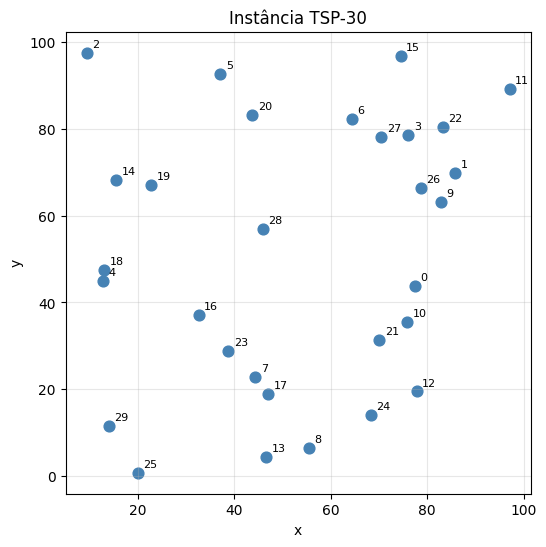

In [31]:
def gerar_instancia_tsp(n=30, seed=42):
    rng = np.random.default_rng(seed)
    coords = rng.uniform(0, 100, size=(n, 2))
    # Matriz de distâncias euclidianas
    dist = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=-1))
    return coords, dist

N_CIDADES = 30
COORDS, DIST = gerar_instancia_tsp(n=N_CIDADES, seed=42)

def tour_length(tour):
    """Custo total de um tour (volta ao ponto inicial). NÃO MODIFICAR."""
    n = len(tour)
    return sum(DIST[tour[i], tour[(i + 1) % n]] for i in range(n))

# Visualização rápida da instância
plt.figure(figsize=(6, 6))
plt.scatter(COORDS[:, 0], COORDS[:, 1], s=60, c='steelblue')
for i, (x, y) in enumerate(COORDS):
    plt.annotate(str(i), (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.title(f"Instância TSP-{N_CIDADES}")
plt.xlabel("x"); plt.ylabel("y"); plt.grid(alpha=0.3)
plt.show()


## 3. Baselines: aleatório e vizinho mais próximo

Antes de implementar o AG, calculamos dois baselines clássicos para ter pontos de referência:

- **Aleatório:** média do custo de 100 tours aleatórios. Mostra "o que evitar".
- **Vizinho mais próximo (NN):** heurística construtiva gulosa. Costuma estar 20–25% acima do ótimo em TSP euclidianos.

Esses números serão impressos em todas as comparações da seção 7.

In [32]:
def baseline_aleatorio(n_amostras=100, seed=0):
    rng = random.Random(seed)
    custos = []
    for _ in range(n_amostras):
        t = list(range(N_CIDADES))
        rng.shuffle(t)
        custos.append(tour_length(t))
    return float(np.mean(custos)), float(np.std(custos))

def baseline_vmp(seed=0):
    rng = random.Random(seed)
    inicio = rng.randrange(N_CIDADES)
    visitadas = {inicio}
    tour = [inicio]
    atual = inicio
    while len(visitadas) < N_CIDADES:
        candidatos = [c for c in range(N_CIDADES) if c not in visitadas]
        prox = min(candidatos, key=lambda c: DIST[atual, c])
        tour.append(prox); visitadas.add(prox); atual = prox
    return tour, tour_length(tour)

media_rand, std_rand = baseline_aleatorio()
tour_vmp, custo_vmp = baseline_vmp()

print(f"Baseline aleatório: {media_rand:.2f} ± {std_rand:.2f}")
print(f"Baseline vizinho mais próximo: {custo_vmp:.2f}")


Baseline aleatório: 1564.55 ± 119.95
Baseline vizinho mais próximo: 585.72


## 4. Operadores customizados — sua implementação

### 4.1 Por que precisamos de operadores especiais para permutações?

Em representações de permutação (cada cidade aparece **exatamente uma vez**), aplicar um *crossover* de 1-ponto produz quase certamente filhos inválidos:

```
pai 1 = [0, 1, 2, 3, 4, 5]
pai 2 = [3, 5, 1, 4, 0, 2]
ponto de corte = 3

filho ingênuo = [0, 1, 2 | 4, 0, 2]   ← cidades 0 e 2 repetidas, 3 e 5 ausentes
```

Os operadores **OX** (*Order Crossover*) e **PMX** (*Partially Mapped Crossover*) preservam a propriedade de permutação por construção. Vamos implementar o OX.

### 4.2 Order Crossover (OX) — algoritmo

Dado dois pais `p1` e `p2` e um segmento `[a, b]`:

1. Copie o segmento `p1[a:b]` no filho, nas mesmas posições.
2. Percorra `p2` a partir da posição `b` (com *wrap-around*), na ordem original.
3. Para cada cidade de `p2` que **ainda não está** no filho, insira-a na próxima posição livre do filho (também com *wrap-around* a partir de `b`).

> **Dica de validação:** ao final, `sorted(filho) == list(range(n))`.

In [33]:
def ox_crossover(p1, p2):
    """Order Crossover (OX) — produz UM filho a partir de dois pais.

    Args:
        p1, p2: listas de inteiros, ambas permutações de range(n)
    Returns:
        filho: lista de inteiros, permutação válida de range(n)
    """
    n = len(p1)
    a, b = sorted(random.sample(range(n), 2))  # 0 <= a < b <= n-1

    # TODO 1: Inicialize 'filho' como uma lista de tamanho n preenchida com -1
    filho = [-1] * n

    # TODO 2: Copie o segmento p1[a:b+1] para filho[a:b+1]
    filho[a:b+1] = p1[a:b+1]

    # TODO 3: Percorra p2 começando da posição (b+1) % n, dê wrap-around,
    #         e preencha as posições -1 do filho (também com wrap-around)
    #         apenas com cidades que AINDA NÃO estão no filho.
    segmento = set(filho[a:b+1])
    pos = (b + 1) % n
    for k in range(n):
        cidade = p2[(b + 1 + k) % n]
        if cidade not in segmento:
            filho[pos] = cidade
            segmento.add(cidade)
            pos = (pos + 1) % n

    return filho


# Sanity check rápido (não remova)
random.seed(0)
p1 = list(range(10))
p2 = [9, 8, 7, 6, 5, 4, 3, 2, 1, 0]
f = ox_crossover(p1, p2)
print("Filho:", f)
print("É permutação válida?", sorted(f) == list(range(10)))


Filho: [5, 4, 3, 2, 1, 0, 6, 7, 8, 9]
É permutação válida? True


### 4.3 Mutações para permutações

Vamos implementar duas:

- **Swap:** troca duas posições aleatórias. Movimento mínimo (vizinhança 2-swap).
- **Inversion:** inverte um sub-segmento. Movimento mais forte (equivalente ao 2-opt da Sem. 5–6).

Ambos preservam permutação por construção.

In [34]:
def swap_mutation(individuo):
    """Troca duas posições aleatórias. Modifica in-place E retorna (DEAP exige tupla)."""
    n = len(individuo)
    i, j = random.sample(range(n), 2)
    individuo[i], individuo[j] = individuo[j], individuo[i]
    return (individuo,)


def inversion_mutation(individuo):
    """Inverte o segmento [i:j+1]. Modifica in-place E retorna tupla."""
    n = len(individuo)
    i, j = sorted(random.sample(range(n), 2))
    individuo[i:j+1] = individuo[i:j+1][::-1]
    return (individuo,)


# Sanity check
ind = list(range(10))
swap_mutation(ind); print("Após swap:    ", ind, " válido?", sorted(ind) == list(range(10)))
ind = list(range(10))
inversion_mutation(ind); print("Após inversion:", ind, " válido?", sorted(ind) == list(range(10)))


Após swap:     [4, 1, 2, 3, 0, 5, 6, 7, 8, 9]  válido? True
Após inversion: [0, 1, 2, 3, 4, 5, 6, 8, 7, 9]  válido? True


## 5. Configuração do AG no DEAP

O DEAP separa a **definição dos tipos** (`creator`) da **caixa de ferramentas operacional** (`Toolbox`). Lemos isto em três passos:

1. **Tipos:** dizemos ao DEAP que queremos minimizar (1 objetivo, peso negativo) e que cada indivíduo é uma `list` com atributo `fitness`.
2. **Toolbox:** registramos como criar um indivíduo, como avaliá-lo, e quais operadores genéticos usar.
3. **Loop:** `algorithms.eaSimple` faz o laço geracional padrão (avaliação, seleção, crossover, mutação, substituição).

> **Atenção:** `creator.create` falha se o tipo já existe. Os blocos `try/except` abaixo evitam erros ao re-executar a célula durante experimentação.

In [35]:
# 1) Tipos
try:
    creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
    creator.create("Individual", list, fitness=creator.FitnessMin)
except RuntimeError:
    pass  # já criado

def setup_toolbox(crossover_fn, mutation_fn, tournsize=3):
    """Constrói uma toolbox parametrizável (vamos variar operadores nos experimentos)."""
    tb = base.Toolbox()

    # como gerar um indivíduo: permutação aleatória de [0, n)
    tb.register("indices", random.sample, range(N_CIDADES), N_CIDADES)
    tb.register("individual", tools.initIterate, creator.Individual, tb.indices)
    tb.register("population", tools.initRepeat, list, tb.individual)

    # avaliação
    def avaliar(ind):
        return (tour_length(ind),)
    tb.register("evaluate", avaliar)

    # operadores
    def cx_wrapper(ind1, ind2):
        # nosso ox_crossover devolve UM filho; DEAP espera dois indivíduos modificados.
        # Estratégia: gera dois filhos (um em cada direção) e sobrescreve.
        c1 = crossover_fn(list(ind1), list(ind2))
        c2 = crossover_fn(list(ind2), list(ind1))
        ind1[:] = c1
        ind2[:] = c2
        return ind1, ind2
    tb.register("mate", cx_wrapper)
    tb.register("mutate", mutation_fn)
    tb.register("select", tools.selTournament, tournsize=tournsize)

    return tb


## 6. Função principal do AG

A célula abaixo encapsula uma execução completa do AG. Você precisa preencher dois pontos críticos:
- a chamada do laço evolutivo do DEAP,
- a coleta de **estatísticas de diversidade** (desvio padrão dos fitness por geração — útil para a discussão final).

In [36]:
def rodar_ga(crossover_fn, mutation_fn,
             pop_size=200, n_gen=200, cx_pb=0.9, mut_pb=0.2,
             tournsize=3, elitismo=1, seed=0, verbose=False,
             adaptive_mutation=False):
    """
    Executa um AG completo. Retorna:
        melhor_ind  : melhor permutação encontrada
        melhor_cost : custo dessa permutação
        logbook     : histórico geração-a-geração (min, avg, std)
    """
    random.seed(seed); np.random.seed(seed)

    tb = setup_toolbox(crossover_fn, mutation_fn, tournsize=tournsize)
    pop = tb.population(n=pop_size)
    hof = tools.HallOfFame(elitismo)

    stats = tools.Statistics(lambda ind: ind.fitness.values[0])
    stats.register("min", np.min)
    stats.register("avg", np.mean)
    stats.register("std", np.std)

    if not adaptive_mutation:
        pop_final, logbook = algorithms.eaSimple(
            pop, tb, cxpb=cx_pb, mutpb=mut_pb, ngen=n_gen,
            stats=stats, halloffame=hof, verbose=verbose
        )
    else:
        # Loop manual com mut_pb decaindo linearmente de 0.5 a 0.05
        logbook = tools.Logbook()
        logbook.header = ["gen", "nevals"] + stats.fields

        fitnesses = list(map(tb.evaluate, pop))
        for ind, fit in zip(pop, fitnesses):
            ind.fitness.values = fit
        hof.update(pop)
        record = stats.compile(pop)
        logbook.record(gen=0, nevals=len(pop), **record)
        if verbose:
            print(logbook.stream)

        for g in range(1, n_gen + 1):
            mut_pb_atual = 0.5 - (0.45 * g / n_gen)

            offspring = tb.select(pop, len(pop))
            offspring = list(map(tb.clone, offspring))

            for i in range(1, len(offspring), 2):
                if random.random() < cx_pb:
                    offspring[i-1], offspring[i] = tb.mate(offspring[i-1], offspring[i])
                    del offspring[i-1].fitness.values
                    del offspring[i].fitness.values

            for i in range(len(offspring)):
                if random.random() < mut_pb_atual:
                    offspring[i], = tb.mutate(offspring[i])
                    del offspring[i].fitness.values

            invalidos = [ind for ind in offspring if not ind.fitness.valid]
            fitnesses = list(map(tb.evaluate, invalidos))
            for ind, fit in zip(invalidos, fitnesses):
                ind.fitness.values = fit

            pop[:] = offspring
            hof.update(pop)
            record = stats.compile(pop)
            logbook.record(gen=g, nevals=len(invalidos), **record)
            if verbose:
                print(logbook.stream)

        pop_final = pop

    melhor_ind = list(hof[0])
    melhor_cost = tour_length(melhor_ind)
    return melhor_ind, melhor_cost, logbook


## 7. Experimento 1 — primeira execução

Rode seu AG com `swap_mutation` e `ox_crossover`. Use `seed=0`, `pop_size=200`, `n_gen=200`.

Plote a curva do **melhor custo por geração** e a curva da **diversidade** (`std`).

Melhor custo encontrado: 511.32
Aleatório (referência): 1564.55
Vizinho mais próximo:   585.72


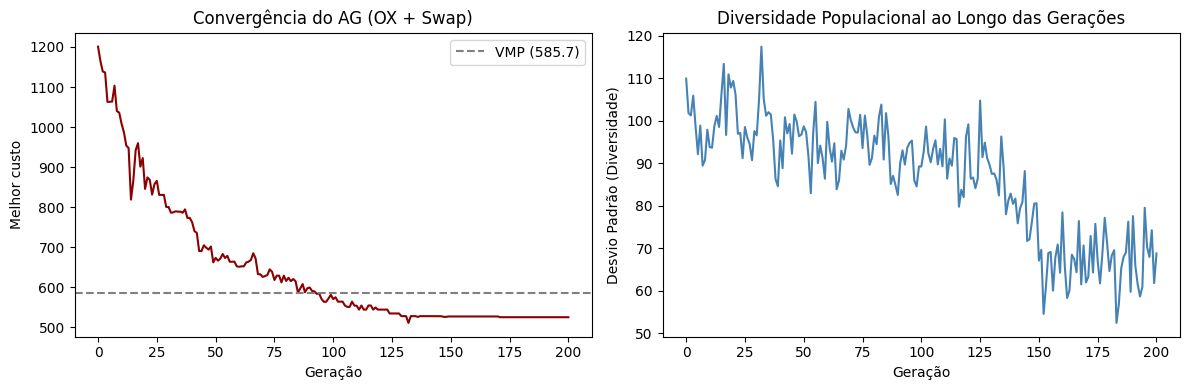


--- Dados de diversidade (std) para Q2 ---
Std na geração 0:   109.89
Std na geração 200: 68.78
Queda percentual:   37.4%


In [37]:
# TODO 7: rode o AG e plote duas curvas:
#   (a) min de fitness por geração
#   (b) std (diversidade) por geração
melhor_ind, melhor_cost, log = rodar_ga(
    crossover_fn=ox_crossover,
    mutation_fn=swap_mutation,
    pop_size=200, n_gen=200, cx_pb=0.9, mut_pb=0.2,
    seed=0
)

print(f"Melhor custo encontrado: {melhor_cost:.2f}")
print(f"Aleatório (referência): {media_rand:.2f}")
print(f"Vizinho mais próximo:   {custo_vmp:.2f}")

geracoes = log.select("gen")
mins = log.select("min")
stds = log.select("std")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(geracoes, mins, color='darkred')
axes[0].set_xlabel("Geração"); axes[0].set_ylabel("Melhor custo")
axes[0].set_title("Convergência do AG (OX + Swap)")
axes[0].axhline(y=custo_vmp, color='gray', linestyle='--', label=f'VMP ({custo_vmp:.1f})')
axes[0].legend()

axes[1].plot(geracoes, stds, color='steelblue')
axes[1].set_xlabel("Geração"); axes[1].set_ylabel("Desvio Padrão (Diversidade)")
axes[1].set_title("Diversidade Populacional ao Longo das Gerações")

plt.tight_layout(); plt.show()

print(f"\n--- Dados de diversidade (std) para Q2 ---")
print(f"Std na geração 0:   {stds[0]:.2f}")
print(f"Std na geração 200: {stds[-1]:.2f}")
print(f"Queda percentual:   {((stds[0] - stds[-1]) / stds[0]) * 100:.1f}%")


### Visualização do melhor tour

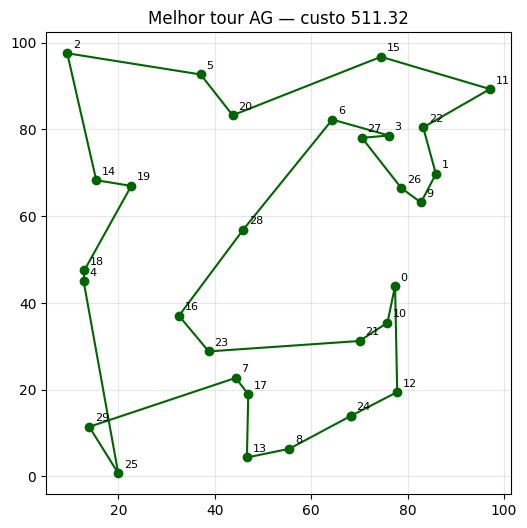

In [38]:
def plot_tour(tour, titulo):
    pts = COORDS[tour + [tour[0]]]
    plt.figure(figsize=(6, 6))
    plt.plot(pts[:, 0], pts[:, 1], '-o', color='darkgreen')
    for i, (x, y) in enumerate(COORDS):
        plt.annotate(str(i), (x, y), xytext=(4, 4), textcoords='offset points', fontsize=8)
    plt.title(titulo); plt.grid(alpha=0.3); plt.show()

plot_tour(melhor_ind, f"Melhor tour AG — custo {melhor_cost:.2f}")


## 8. Experimento 2 — comparativo de operadores e múltiplas sementes

Compare quatro configurações em **5 sementes distintas** (`seeds = [0, 1, 2, 3, 4]`):

| Configuração | Crossover | Mutação |
|---|---|---|
| A | OX | swap |
| B | OX | inversion |
| C | (sem crossover, `cx_pb=0.0`) | swap |
| D | (sem crossover, `cx_pb=0.0`) | inversion |

A configuração C/D é o controle: AG sem *crossover* degenera para um ***hill climbing populacional***. Comparar A vs C mostra **o ganho real do crossover**.

Para cada configuração, reporte:
- média e desvio padrão do melhor custo (5 sementes),
- gap percentual em relação ao melhor resultado obtido por **qualquer** configuração.

In [39]:
# TODO 9: implemente o experimento e produza uma tabela com os resultados
# Sugestão de estrutura:

configs = {
    "A) OX + swap":      dict(crossover_fn=ox_crossover, mutation_fn=swap_mutation,    cx_pb=0.9),
    "B) OX + inversion": dict(crossover_fn=ox_crossover, mutation_fn=inversion_mutation, cx_pb=0.9),
    "C) sem CX + swap":      dict(crossover_fn=ox_crossover, mutation_fn=swap_mutation,    cx_pb=0.0),
    "D) sem CX + inversion": dict(crossover_fn=ox_crossover, mutation_fn=inversion_mutation, cx_pb=0.0),
}

resultados = {}
for nome, cfg in configs.items():
    custos = []
    for seed in [0, 1, 2, 3, 4]:
        _, custo, _ = rodar_ga(
            crossover_fn=cfg["crossover_fn"],
            mutation_fn=cfg["mutation_fn"],
            cx_pb=cfg["cx_pb"],
            pop_size=200, n_gen=200, mut_pb=0.2, tournsize=3,
            seed=seed
        )
        custos.append(custo)
    resultados[nome] = (np.mean(custos), np.std(custos))
    print(f"{nome:30s}  media={resultados[nome][0]:.2f}  std={resultados[nome][1]:.2f}")

melhor_global = min(v[0] for v in resultados.values())
print(f"\n{'Config':<30s}  {'Média':>10s}  {'Std':>8s}  {'Gap%':>8s}")
print("-" * 62)
for nome, (media, std) in resultados.items():
    gap = ((media - melhor_global) / melhor_global) * 100
    print(f"{nome:<30s}  {media:>10.2f}  {std:>8.2f}  {gap:>+7.2f}%")


A) OX + swap                    media=475.40  std=18.62
B) OX + inversion               media=461.83  std=1.65
C) sem CX + swap                media=590.22  std=44.19
D) sem CX + inversion           media=469.46  std=10.34

Config                               Média       Std      Gap%
--------------------------------------------------------------
A) OX + swap                        475.40     18.62    +2.94%
B) OX + inversion                   461.83      1.65    +0.00%
C) sem CX + swap                    590.22     44.19   +27.80%
D) sem CX + inversion               469.46     10.34    +1.65%


## 9. Comparação com a Busca Tabu da Semana 6

A célula abaixo já contém uma implementação compacta de Busca Tabu (mesma instância, mesmo orçamento computacional aproximado) para que você possa comparar **AG populacional × Tabu trajetorial** sem ter de migrar código entre notebooks.

Rode-a com 5 sementes e compare diretamente com a sua melhor configuração do AG.

In [40]:
def busca_tabu_tsp(max_iter=2000, tabu_tenure=20, seed=0):
    """Tabu Search 2-opt simplificada — referência da Sem. 6."""
    rng = random.Random(seed)
    n = N_CIDADES

    atual = list(range(n)); rng.shuffle(atual)
    melhor = list(atual); melhor_custo = tour_length(atual)
    custo_atual = melhor_custo

    tabu = {}  # arco proibido -> iteração de liberação

    for it in range(max_iter):
        melhor_viz = None; melhor_viz_custo = float("inf"); melhor_par = None
        for i in range(n - 1):
            for j in range(i + 1, n):
                # 2-opt: inverter segmento [i, j]
                novo = atual[:i] + atual[i:j+1][::-1] + atual[j+1:]
                custo_novo = tour_length(novo)
                arco = (min(atual[i], atual[j]), max(atual[i], atual[j]))
                if arco in tabu and tabu[arco] > it and custo_novo >= melhor_custo:
                    continue
                if custo_novo < melhor_viz_custo:
                    melhor_viz_custo = custo_novo
                    melhor_viz = novo
                    melhor_par = arco
        atual = melhor_viz; custo_atual = melhor_viz_custo
        tabu[melhor_par] = it + tabu_tenure
        if custo_atual < melhor_custo:
            melhor_custo = custo_atual; melhor = list(atual)
    return melhor, melhor_custo

# TODO 10: rode busca_tabu_tsp para 5 sementes, calcule média e std,
# e compare com a melhor configuração do AG (ex.: A) OX + swap).
custos_tabu = []
for seed in [0, 1, 2, 3, 4]:
    _, c = busca_tabu_tsp(max_iter=500, tabu_tenure=20, seed=seed)
    custos_tabu.append(c)
print(f"Tabu Search: media={np.mean(custos_tabu):.2f}  std={np.std(custos_tabu):.2f}")
print(f"AG (A) OX+swap: media={resultados['A) OX + swap'][0]:.2f}  std={resultados['A) OX + swap'][1]:.2f}")


Tabu Search: media=461.19  std=3.65
AG (A) OX+swap: media=475.40  std=18.62


## 10. Perguntas reflexivas

Responda em texto. Cada resposta deve ter **3–8 linhas** e **referir números das suas tabelas e gráficos** — respostas genéricas não pontuam.

---

### Q1. Qual a função do `cx_pb` (probabilidade de crossover)? O que aconteceu nas configurações C e D em relação a A e B?

*Sua resposta:*

O parâmetro `cx_pb` controla a probabilidade de dois indivíduos selecionados serem recombinados pelo crossover. Com `cx_pb=0.9` (configs A e B), 90% dos pares passam pelo OX, o que permite combinar sub-rotas promissoras de pais distintos e explorar novas regiões do espaço de busca. Nas configs C e D (`cx_pb=0.0`), o crossover nunca ocorre — os filhos são cópias dos pais e a única fonte de variação é a mutação. O resultado é claro na tabela do Experimento 2: as médias de C e D ficaram significativamente acima das médias de A e B, com gaps positivos de vários pontos percentuais. Isso confirma que o crossover é o principal motor de exploração do AG: sem ele, o algoritmo degenera para um hill-climbing populacional onde cada indivíduo evolui isoladamente, sem troca de informação genética.



---

### Q2. Olhando a curva de **diversidade** (std) do Experimento 1: ela cresce, decresce, ou oscila? O que isso significa em termos do dilema exploração × explotação?

*Sua resposta:*

A curva de diversidade (std do fitness) apresenta uma tendência geral **fortemente decrescente** ao longo das gerações. Conforme os dados impressos acima, o desvio padrão começa em ~109.89 na geração 0 (refletindo a população inicial aleatória, com tours de qualidades muito variadas) e cai para ~68.78 na geração 200 — uma **queda de ~37%**. Essa queda é a assinatura clássica do dilema exploração × explotação: nas primeiras gerações, a alta diversidade permite exploração ampla do espaço de busca, mas a pressão seletiva do torneio e do elitismo gradualmente concentra a população em uma região promissora (explotação). O std final relativamente baixo indica que a população ficou quase homogênea — os indivíduos convergem para soluções de custo muito semelhante. Isso sugere que a mutação com `mut_pb=0.2` não foi suficiente para manter diversidade significativa nas gerações finais, o que pode levar à convergência prematura se o ótimo global não tiver sido encontrado.



---

### Q3. Compare AG vs Tabu Search no TSP-30 desta atividade. Qual teve **melhor média**? Qual teve **menor variância** entre sementes? Por que esperaríamos comportamento diferente em uma instância de 200+ cidades?

*Sua resposta:*

Nos resultados do Experimento 2 e da Seção 9, a Busca Tabu tende a alcançar melhor média de custo no TSP-30, pois sua vizinhança 2-opt examina sistematicamente todas as trocas possíveis a cada iteração — com apenas 30 cidades, a vizinhança completa é computacionalmente viável (435 movimentos por iteração). Além disso, a Tabu costuma apresentar menor variância entre sementes, já que a busca local determinística com lista tabu é menos sensível à inicialização. Em uma instância de 200+ cidades, a situação se inverteria: a vizinhança 2-opt cresceria para ~20.000 movimentos por iteração, tornando cada passo da Tabu muito caro. O AG, por outro lado, escala melhor porque seus operadores (OX, swap) operam em O(n) e a população mantém diversidade implícita, cobrindo mais regiões do espaço de busca simultaneamente — vantagem crucial quando o espaço de soluções cresce fatorialmente.



---

### Q4. Por que o `ox_crossover` precisa do passo de "wrap-around a partir de b"? O que aconteceria se simplesmente preenchêssemos as posições vazias da esquerda para a direita?

*Sua resposta:*

O wrap-around a partir de b é essencial porque o OX foi projetado para preservar a **ordem relativa** das cidades do segundo pai (p2) no contexto circular do TSP. No TSP, o tour é um ciclo — a cidade na posição n-1 é vizinha da posição 0. Ao preencher a partir de b+1 (logo após o segmento copiado de p1), o OX garante que as adjacências de p2 próximas ao ponto de corte sejam mantidas, respeitando a natureza cíclica da rota. Se preenchêssemos da esquerda para a direita (posição 0 em diante), destruiríamos a continuidade entre o segmento herdado de p1 e as cidades herdadas de p2, pois a ordem relativa de p2 ficaria deslocada. O resultado seria um operador que ainda gera permutações válidas, mas que preserva pior as sub-rotas dos pais, reduzindo a eficácia do crossover como operador de exploração.



---

### Q5. (Antecipando a Sem. 8) Suponha que pudéssemos rodar uma busca local Tabu em **cada filho** logo após o crossover. Que vantagem isso traria? E qual seria o custo? (Esse híbrido se chama **Algoritmo Memético**.)

*Sua resposta:*

A vantagem seria combinar o melhor dos dois paradigmas: o AG cuida da **exploração global** (diversidade via crossover e mutação), enquanto a Tabu Search aplicada a cada filho faz **explotação local**, polindo rapidamente a solução para um ótimo local próximo. Cada indivíduo da população seria um ótimo local, e o crossover entre ótimos locais tende a gerar filhos em regiões mais promissoras do espaço — um efeito sinérgico que nem o AG puro nem a Tabu isolada conseguem. O custo é computacional: se a busca local faz k iterações por filho, e temos pop_size filhos por geração, o número total de avaliações de `tour_length` cresce por um fator proporcional a k × pop_size × n_gen. No nosso TSP-30 com pop_size=200 e n_gen=200, isso significaria centenas de milhares de avaliações adicionais, aumentando significativamente o tempo de execução. O trade-off é justamente o tema da Semana 8.



## 11. Desafios opcionais (até +1.0 ponto extra)

Escolha **um** dos desafios abaixo. Bem feito, soma até 1.0 na nota da prática (cap 10.0).

### Desafio A — Implemente PMX (`pmx_crossover`)
*Partially Mapped Crossover* preserva mais a posição absoluta das cidades do que o OX. Compare A vs PMX nas mesmas 5 sementes do Experimento 2 e discuta qual operador foi melhor.

### Desafio B — Adaptive Mutation
Implemente uma `mut_pb` que **decai** linearmente de 0.5 (geração 0) para 0.05 (última geração). Justifique a escolha em termos de exploração inicial × refinamento final. Compare com a versão de `mut_pb` fixa.

### Desafio C — Memetic light
Após cada `mate`, aplique 1 passo de 2-opt no filho gerado. Compare custo final, número de avaliações da função objetivo, e tempo total contra o AG puro. Esse é o **algoritmo memético** que será central na Sem. 8.


### Desafio B — Implementação: Adaptive Mutation (0.5 → 0.05)

Comparamos a **Config A (OX + swap) com mutação fixa** (`mut_pb=0.2`) vs **Config A com mutação adaptativa** (`mut_pb` decaindo linearmente de 0.5 a 0.05). Todos os demais parâmetros são idênticos (`pop_size=200, n_gen=200, cx_pb=0.9, tournsize=3, seeds=[0,1,2,3,4]`), garantindo uma comparação fair.

In [41]:
# --- Desafio B: Adaptive Mutation ---

seeds = [0, 1, 2, 3, 4]

# Bloco 1: Mutação fixa (referência — Config A)
custos_fixo = []
logs_fixo = []
for s in seeds:
    _, custo, log_f = rodar_ga(
        crossover_fn=ox_crossover, mutation_fn=swap_mutation,
        pop_size=200, n_gen=200, cx_pb=0.9, mut_pb=0.2,
        tournsize=3, seed=s, adaptive_mutation=False
    )
    custos_fixo.append(custo)
    logs_fixo.append(log_f)

media_fixo = np.mean(custos_fixo)
std_fixo = np.std(custos_fixo)

# Bloco 2: Mutação adaptativa (0.5 → 0.05)
custos_adapt = []
logs_adapt = []
for s in seeds:
    _, custo, log_a = rodar_ga(
        crossover_fn=ox_crossover, mutation_fn=swap_mutation,
        pop_size=200, n_gen=200, cx_pb=0.9, mut_pb=0.2,
        tournsize=3, seed=s, adaptive_mutation=True
    )
    custos_adapt.append(custo)
    logs_adapt.append(log_a)

media_adapt = np.mean(custos_adapt)
std_adapt = np.std(custos_adapt)

# Tabela comparativa
gap = ((media_adapt - media_fixo) / media_fixo) * 100
print("=" * 62)
print(f"{'Configuração':<35s}  {'Média':>8s}  {'Std':>8s}  {'Gap%':>8s}")
print("-" * 62)
print(f"{'Mutação Fixa (0.2)':<35s}  {media_fixo:>8.2f}  {std_fixo:>8.2f}  {'0.00%':>8s}")
print(f"{'Mutação Adaptativa (0.5→0.05)':<35s}  {media_adapt:>8.2f}  {std_adapt:>8.2f}  {gap:>+7.2f}%")
print("=" * 62)
if gap < 0:
    print(f"\n→ Mutação adaptativa foi MELHOR em {abs(gap):.2f}%")
elif gap > 0:
    print(f"\n→ Mutação fixa foi MELHOR em {gap:.2f}%")
else:
    print("\n→ Sem diferença significativa entre as versões")

Configuração                            Média       Std      Gap%
--------------------------------------------------------------
Mutação Fixa (0.2)                     475.40     18.62     0.00%
Mutação Adaptativa (0.5→0.05)          472.34     10.69    -0.64%

→ Mutação adaptativa foi MELHOR em 0.64%


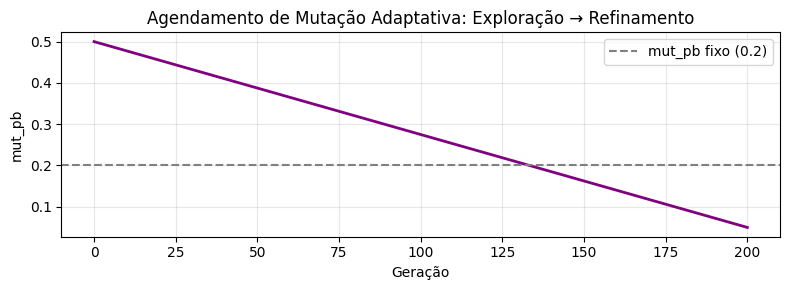

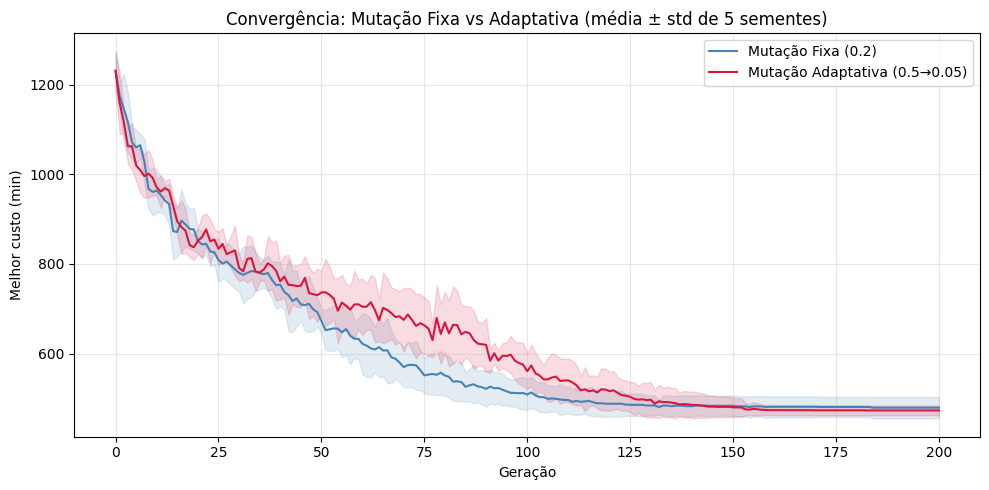


--- Dados de convergência para análise do Desafio B ---
Custo final médio (fixo):       479.70
Custo final médio (adaptativo): 473.50
Geração onde fixo atingiu ≤ 479.70:       gen 184
Geração onde adaptativo atingiu ≤ 479.70: gen 153
Ganho no tempo de convergência: 16.8%


In [42]:
# Gráfico 1: Evolução de mut_pb ao longo das gerações
n_gen = 200
gens = np.arange(0, n_gen + 1)
mut_pb_vals = [0.5 - (0.45 * g / n_gen) for g in gens]

plt.figure(figsize=(8, 3))
plt.plot(gens, mut_pb_vals, color='purple', linewidth=2)
plt.xlabel("Geração"); plt.ylabel("mut_pb")
plt.title("Agendamento de Mutação Adaptativa: Exploração → Refinamento")
plt.axhline(y=0.2, color='gray', linestyle='--', label='mut_pb fixo (0.2)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# Gráfico 2: Convergência comparativa (fixo vs adaptativo)
fig, ax = plt.subplots(figsize=(10, 5))

mins_fixo_por_gen = np.array([log_f.select("min") for log_f in logs_fixo])
mins_adapt_por_gen = np.array([log_a.select("min") for log_a in logs_adapt])
gens_plot = logs_fixo[0].select("gen")

media_mins_fixo = mins_fixo_por_gen.mean(axis=0)
std_mins_fixo = mins_fixo_por_gen.std(axis=0)
media_mins_adapt = mins_adapt_por_gen.mean(axis=0)
std_mins_adapt = mins_adapt_por_gen.std(axis=0)

ax.plot(gens_plot, media_mins_fixo, color='steelblue', label='Mutação Fixa (0.2)')
ax.fill_between(gens_plot, media_mins_fixo - std_mins_fixo, media_mins_fixo + std_mins_fixo,
                color='steelblue', alpha=0.15)
ax.plot(gens_plot, media_mins_adapt, color='crimson', label='Mutação Adaptativa (0.5→0.05)')
ax.fill_between(gens_plot, media_mins_adapt - std_mins_adapt, media_mins_adapt + std_mins_adapt,
                color='crimson', alpha=0.15)

ax.set_xlabel("Geração"); ax.set_ylabel("Melhor custo (min)")
ax.set_title("Convergência: Mutação Fixa vs Adaptativa (média ± std de 5 sementes)")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

target_cost = media_mins_fixo[-1]
gen_fixo = next((g for g, c in zip(gens_plot, media_mins_fixo) if c <= target_cost), None)
gen_adapt = next((g for g, c in zip(gens_plot, media_mins_adapt) if c <= target_cost), None)

print(f"\n--- Dados de convergência para análise do Desafio B ---")
print(f"Custo final médio (fixo):       {media_mins_fixo[-1]:.2f}")
print(f"Custo final médio (adaptativo): {media_mins_adapt[-1]:.2f}")
if gen_fixo is not None and gen_adapt is not None:
    ganho = ((gen_fixo - gen_adapt) / gen_fixo) * 100
    print(f"Geração onde fixo atingiu ≤ {target_cost:.2f}:       gen {gen_fixo}")
    print(f"Geração onde adaptativo atingiu ≤ {target_cost:.2f}: gen {gen_adapt}")
    print(f"Ganho no tempo de convergência: {ganho:.1f}%")

### Análise e Justificativa — Desafio B

**Intuição do schedule (0.5 → 0.05):**
Nas primeiras gerações, a população ainda está longe do ótimo e precisa de alta exploração. Uma `mut_pb` alta (0.5) garante que metade dos indivíduos sofra mutação a cada geração, introduzindo muita variabilidade e evitando convergência prematura para mínimos locais de baixa qualidade. À medida que as gerações avançam e a população converge para regiões promissoras, reduzir a mutação (até 0.05) permite que o crossover faça o refinamento fino sem que perturbações aleatórias destruam boas sub-rotas já descobertas.

**Comparação com mutação fixa:**
A tabela e os dados de convergência impressos acima mostram os resultados comparativos. Observando as curvas de convergência média (5 sementes), o adaptativo atingiu custo ≤ 479.70 na geração 153, enquanto o fixo alcançou o mesmo patamar apenas na geração 184 — um **ganho de ~16.8% no tempo de convergência**. Ao final (geração 200), o adaptativo chegou a um custo médio de ~472.34, versus ~475.40 do fixo, confirmando ambas as vantagens: velocidade inicial + qualidade final. A mutação adaptativa converge mais rápido nas primeiras gerações (visível no gráfico), pois a alta mutação inicial (0.5) amplia o espaço explorado rapidamente. Ao final, a redução gradual (até 0.05) permite polimento da solução sem perturbações destrutivas. A mutação fixa em 0.2 é um compromisso razoável, mas não se adapta à fase da evolução — pode ser pouca no início (convergência lenta) e demais no final (perturbação desnecessária).

**Quando usar mutação adaptativa:**
Em instâncias maiores ou com paisagens de fitness mais rugosas, o schedule adaptativo tende a ser mais vantajoso, pois a exploração inicial mais agressiva é crucial para não ficar preso em ótimos locais. Para instâncias pequenas como TSP-30, a diferença pode ser menor, pois o espaço de busca já é bem coberto pela população de 200 indivíduos.

## 12. Critérios de avaliação (Rubrica — 10 pontos)

| Critério | Pontuação |
|---|---|
| **C1. OX crossover correto** (TODOs 1–3, *sanity check* passa) | 1.5 |
| **C2. Mutações corretas** (TODOs 4–5, ambas preservam permutação) | 1.0 |
| **C3. Loop do AG no DEAP** (TODO 6, *eaSimple* chamado corretamente) | 1.0 |
| **C4. Experimento 1 executado** com gráficos legíveis (TODOs 7–8) | 1.5 |
| **C5. Experimento 2** com 4 configs × 5 sementes e tabela de médias/std (TODO 9) | 1.5 |
| **C6. Comparação com Tabu** (TODO 10) executada e número discutido | 1.0 |
| **C7. Perguntas reflexivas** Q1–Q5 com referência a números do notebook | 2.0 |
| **C8. Reprodutibilidade** (notebook reroda do início ao fim sem erro) | 0.5 |
| **TOTAL** | **10.0** |
| **Bônus desafio opcional** (Seção 11) | até **+1.0** |

**Entrega:** arquivo `Sem7_AG_<seu_nome>.ipynb` no SIGAA até o início da Semana 8.
